In [26]:
!pip install fredapi pandas matplotlib seaborn plotly lime shap

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from fredapi import Fred
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.autograd import Variable


In [27]:
# Fetch data from FRED API
fred = Fred(api_key='e956a3dbccd7d4f90be734f8d55b1d07')

# Features and Target
series_ids = {
    'RSAFS': 'Retail Sales: All Food Services (Target)',
    'CPIAUCSL': 'Consumer Price Index',
    'UNRATE': 'Unemployment Rate',
    'FEDFUNDS': 'Federal Funds Rate',
    'PCE': 'Personal Consumption Expenditures',
    'DSPIC96': 'Real Disposable Personal Income'
}

# Data from FRED
data = pd.DataFrame()
for series_id in series_ids:
    data[series_id] = fred.get_series(series_id)

data.index = fred.get_series('RSAFS').index
data.dropna(inplace=True)
data.rename(columns=series_ids, inplace=True)
data.reset_index(inplace=True)
data.rename(columns={'index': 'ds', 'Retail Sales: All Food Services (Target)': 'y'}, inplace=True)

In [28]:
# Convert data to numpy array for PyTorch
X = data.drop(columns=['ds', 'y']).values
y = data['y'].values


In [29]:
# Normalize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [30]:
# Convert to PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

In [31]:
# Train-Test Split
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [32]:
# Create DataLoader for training and testing
train_data = torch.utils.data.TensorDataset(X_train, y_train)
test_data = torch.utils.data.TensorDataset(X_test, y_test)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False)


Epoch 1: Loss = 1.2683
Epoch 2: Loss = 1.2552
Epoch 3: Loss = 1.2494
Epoch 4: Loss = 1.2401
Epoch 5: Loss = 1.2338


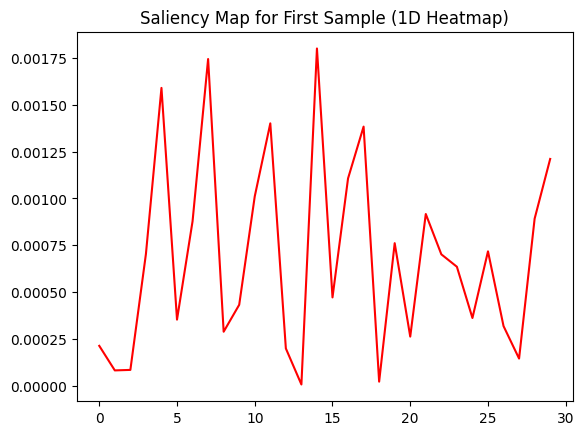

In [33]:
# =======================
# 1. Import Necessary Libraries
# =======================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# =======================
# 2. Define the WaveNet Model Class
# =======================
class WaveNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=32, kernel_size=2):
        super(WaveNet, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, dilation=1, padding=1)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size, dilation=2, padding=2)
        self.conv3 = nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size, dilation=4, padding=4)
        self.conv4 = nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size, dilation=8, padding=8)
        self.fc = nn.Linear(out_channels, 1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.adaptive_avg_pool1d(x, 1)  # Reduce dimensionality
        x = x.squeeze(-1)  # Remove the last dimension
        x = self.fc(x)
        return x

# =======================
# 3. Initialize Model, Optimizer, and Loss Function
# =======================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create the model instance
model = WaveNet(in_channels=1, out_channels=32, kernel_size=2).to(device)

# Initialize optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# =======================
# 4. Data Preparation (Example Input)
# =======================
# Example input tensor (batch size of 64 and 30 time steps, 1 channel)
inputs = torch.randn(64, 1, 30).to(device)  # Shape: (batch_size, channels, time_steps)

# Corresponding labels for the inputs
labels = torch.randn(64, 1).to(device)  # Assuming the labels are continuous (for regression)

# Create DataLoader for training (Using dummy data in this example)
dataset = TensorDataset(inputs, labels)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

# =======================
# 5. Train Model (Dummy Training Loop)
# =======================
def train_model(train_loader, model, optimizer, loss_fn, num_epochs=20):
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}: Loss = {total_loss/len(train_loader):.4f}")

# Train the model (with dummy data for now)
train_model(train_loader, model, optimizer, loss_fn, num_epochs=5)

# =======================
# 6. Saliency Map Calculation
# =======================
def saliency_map(model, input_tensor, target_tensor):
    input_tensor.requires_grad_()  # Enable gradient calculation on input
    model.zero_grad()  # Zero all gradients for the model
    output = model(input_tensor)  # Forward pass to get output
    output.backward(torch.ones_like(output))  # Compute gradients
    saliency, _ = torch.max(input_tensor.grad.data.abs(), dim=1)  # Take the maximum gradient value along the channel dimension
    return saliency

# =======================
# =======================
# 7. Compute Saliency Map
# =======================
# Compute saliency map for the example input
saliency = saliency_map(model, inputs, labels)

# Plot the saliency map as a 1D heatmap
plt.plot(saliency[0].cpu().numpy(), color='red')
plt.title("Saliency Map for First Sample (1D Heatmap)")
plt.show()


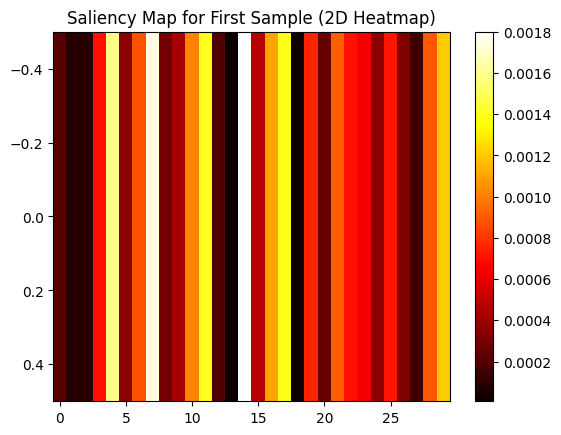

In [46]:
saliency_reshaped = saliency[0].cpu().numpy().reshape(1, -1)

# Plot the saliency map as a 2D heatmap (1x30 image)
plt.imshow(saliency_reshaped, cmap='hot', aspect='auto', interpolation='nearest')
plt.colorbar()
plt.title("Saliency Map for First Sample (2D Heatmap)")
plt.show()

LIME

In [35]:
!pip install lime


In [36]:
import numpy as np
from lime.lime_tabular import LimeTabularExplainer

# Convert a batch to numpy
X_data = inputs.detach().cpu().numpy().squeeze()  # shape (64, 30)
y_data = labels.detach().cpu().numpy().squeeze()  # shape (64,)

# Define a prediction function compatible with LIME
def model_predict(input_numpy):
    input_tensor = torch.tensor(input_numpy, dtype=torch.float32).unsqueeze(1).to(device)  # shape (N, 1, 30)
    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor).cpu().numpy()
    return outputs

# Create LimeTabularExplainer
explainer = LimeTabularExplainer(
    training_data=X_data,
    mode="regression",
    feature_names=[f"t-{i}" for i in range(X_data.shape[1])],
    verbose=True,
    random_state=42
)

# Explain a single prediction (first sample)
i = 0
explanation = explainer.explain_instance(
    X_data[i],
    model_predict,
    num_features=10
)

# Visualize the explanation
explanation.show_in_notebook(show_table=True)


Intercept 0.04626890093783859
Prediction_local [0.04353461]
Right: 0.04550121


ICE

In [39]:
print(f"Shape of X_test: {X_test.shape}")  # Check the number of features (should be 30 or more)


Shape of X_test: torch.Size([80, 5])


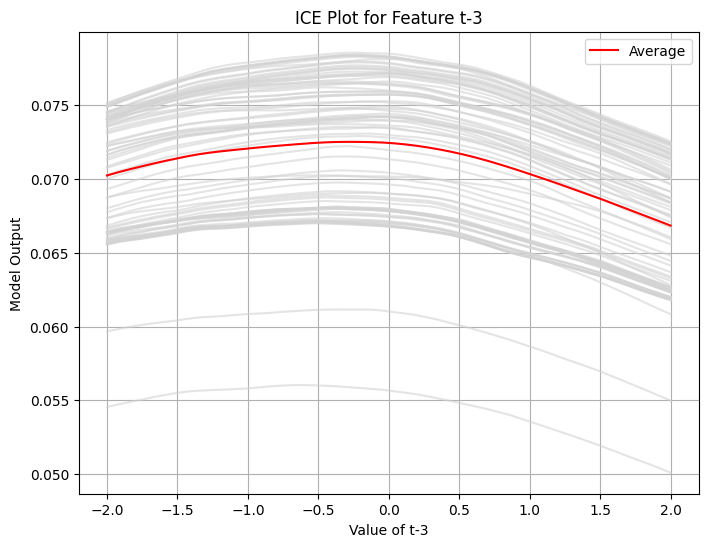

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Select feature index (e.g., feature 3 out of 5)
feature_idx = 3
X = X_test.clone().detach().to(device)  # Shape: (samples, 5)
X_base = X.clone()

# Define range of values for the selected feature
feature_vals = torch.linspace(-2, 2, steps=50).to(device)  # Adjust range if needed

# Store predictions
ice_curves = []

model.eval()
with torch.no_grad():
    for sample in X:
        preds = []
        for val in feature_vals:
            modified_sample = sample.clone()
            modified_sample[feature_idx] = val  # Set selected feature
            output = model(modified_sample.unsqueeze(0))  # Add batch dimension
            preds.append(output.item())
        ice_curves.append(preds)

# Plot ICE curves
plt.figure(figsize=(8, 6))
for curve in ice_curves:
    plt.plot(feature_vals.cpu().numpy(), curve, color='lightgray', alpha=0.6)

plt.plot(feature_vals.cpu().numpy(), np.mean(ice_curves, axis=0), color='red', label='Average')
plt.title(f"ICE Plot for Feature t-{feature_idx}")
plt.xlabel(f"Value of t-{feature_idx}")
plt.ylabel("Model Output")
plt.legend()
plt.grid(True)
plt.show()


PDP

X_test shape: (250, 30)


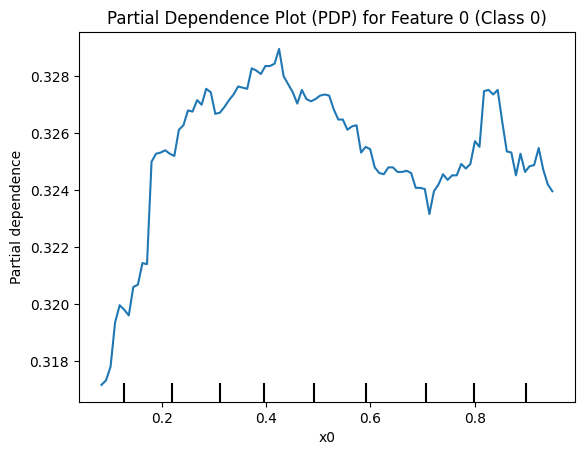

Average Partial Dependence values:
[[0.31716 0.31732 0.3178  0.31936 0.31996 0.3198  0.3196  0.3206  0.32068
  0.32144 0.3214  0.325   0.32528 0.32532 0.3254  0.32528 0.3252  0.32612
  0.32628 0.3268  0.32676 0.32716 0.327   0.32756 0.32744 0.32668 0.32672
  0.32692 0.32716 0.32736 0.32764 0.3276  0.32756 0.32828 0.3282  0.32808
  0.32836 0.32836 0.32844 0.32896 0.328   0.32772 0.32744 0.32704 0.32752
  0.3272  0.32712 0.3272  0.32732 0.32736 0.32732 0.32684 0.32648 0.32648
  0.32612 0.32624 0.32628 0.32532 0.32552 0.32544 0.3248  0.3246  0.32456
  0.3248  0.3248  0.32464 0.32464 0.32468 0.3246  0.32408 0.32408 0.32404
  0.32316 0.32396 0.3242  0.32456 0.32436 0.32452 0.32452 0.32492 0.32476
  0.32492 0.32572 0.32552 0.32748 0.32752 0.32736 0.32752 0.3264  0.32536
  0.32532 0.32452 0.32528 0.32464 0.32484 0.32488 0.32548 0.32472 0.3242
  0.32396]
 [0.32684 0.32488 0.32444 0.32324 0.32316 0.32324 0.324   0.32452 0.32404
  0.32372 0.32388 0.3214  0.32176 0.32212 0.3222  0.32232 0.3224  0

In [41]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay, partial_dependence
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = np.random.rand(1000, 30)
y = np.random.randint(0, 3, size=1000)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("X_test shape:", X_test.shape)

feature = [0]
target_class = 0

PartialDependenceDisplay.from_estimator(rf, X_test, features=feature, target=target_class)
plt.title("Partial Dependence Plot (PDP) for Feature 0 (Class 0)")
plt.show()

results = partial_dependence(rf, X_test, features=feature)

print("Average Partial Dependence values:")
print(results["average"])
print("----------------------------------------------------------")
print("Grid values (the actual values for the input feature):")
print(results["grid_values"])
